In [1]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

from lameg.surf import create_surf_gifti
from lameg.viz import show_surface, color_map, rgbtoint
from lameg.util import get_bigbrain_layer_boundaries, load_meg_sensor_data, convert_native_to_fsaverage
from scipy.signal import correlate
import io
from PIL import Image
from base64 import b64decode
from scipy.io import savemat, loadmat

In [2]:
plt.rcParams.update({
    'font.size': 16,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [3]:
%env SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/
preproc_data_dir='/home/common/bonaiuto/auditory_laminar/derivatives/processed/'

env: SUBJECTS_DIR=/home/common/bonaiuto/auditory_laminar/derivatives/fs/


In [4]:
fsave_lh_coords, fsave_lh_faces = nib.freesurfer.io.read_geometry('/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/fsaverage/surf/lh.inflated')
fsave_lh = create_surf_gifti(fsave_lh_coords, fsave_lh_faces)
lh_curv_data = nib.freesurfer.read_morph_data('/home/common/bonaiuto/cued_action_meg/derivatives/processed/fs/fsaverage/surf/lh.curv')

In [5]:
subjects = [
    'sub-104',
    'sub-105',
    'sub-114'
]
sessions = {
    'sub-104': ['ses-01'],
    'sub-105': ['ses-01'],
    'sub-114': ['ses-01']
}
polarity={
    'sub-104': [1],
    'sub-105': [1],
    'sub-114': [-1]
}
subj_coords={
    subject: [] for subject in subjects
}

time_lims=[-500, 500]
n_layers=11
epo_type='btn_trial'
        
out_dir=os.path.join('/home/bonaiuto/auditory_laminar/output',epo_type,'01_mf/patch_size_5.00mm/')

all_prior_ts=[]
all_layer_F=[]
all_layer_F_diff=[]
all_snrs=[]

for subject in subjects:
    
    for sess_idx, session in enumerate(sessions[subject]):
        session_polarity=polarity[subject][sess_idx]
        out_fname = os.path.join(out_dir,f'results_{subject}_{session}.npz')
        if os.path.exists(out_fname):
            data_dir=os.path.join(preproc_data_dir,subject,session,'spm')
            orig_data_file = f'spm_autoreject-{subject}-{session}-{epo_type}-epo.mat'
            sensor_data, sensor_time, ch_names = load_meg_sensor_data(os.path.join(data_dir, orig_data_file))
            sensor_time=sensor_time
            st_idx=np.where((sensor_time>=time_lims[0]) & (sensor_time<=time_lims[1]))[0]
            sensor_data=sensor_data[:,st_idx,:]
            sensor_time=sensor_time[st_idx]
            # Compute mean signal across trials (shape: n_channels x n_times)
            mean_signal = np.mean(sensor_data, axis=2)
            # Compute residual noise (trial-by-trial deviations from mean)
            noise = sensor_data - mean_signal[:, :, np.newaxis]
            # Compute RMS of signal and noise over channels
            rms_signal = np.sqrt(np.mean(mean_signal**2, axis=0))  # shape: (n_times,)
            rms_noise = np.sqrt(np.mean(np.mean(noise**2, axis=2), axis=0))  # shape: (n_times,)
            # Compute SNR time series in dB
            snr_db = 20 * np.log10(rms_signal / rms_noise)

            subj_surf_dir=os.path.join(preproc_data_dir,subject,'surf')
            ds_pial = nib.load(os.path.join(subj_surf_dir, 'pial.ds.gii'))

            data = np.load(out_fname, allow_pickle=True)
            prior = data['prior']
            prior_ts = data['prior_ts']*1000
            ts_time = data['ts_time']
            Fs = data['Fs']
            wois = data['wois']
            
            prior_coord=ds_pial.darrays[0].data[prior,:]
            hemi, fsave_idx = convert_native_to_fsaverage(subject, subj_surf_dir, subj_coord=prior_coord)
            fsave_coord = fsave_lh_coords[fsave_idx]

            woi_time=np.mean(wois,axis=-1)
            t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
            woi_win=woi_time[t_idx]
            Fs_win=Fs[:,t_idx]

            ts_idx=np.where((ts_time>=time_lims[0]) & (ts_time<=time_lims[1]))[0]
            prior_ts=prior_ts[ts_idx]
            ts_time=ts_time[ts_idx]

            surf_bb_bounds=n_layers*get_bigbrain_layer_boundaries(subject, subj_surf_dir, subj_coord=ds_pial.darrays[0].data[prior,:])
            
            prior_ts = session_polarity*prior_ts

            layers=np.arange(n_layers)
            layer1_idx=np.where((layers<surf_bb_bounds[0]))[0]
            layer2_idx=np.where((layers>=surf_bb_bounds[0]) & (layers<surf_bb_bounds[1]))[0]
            layer3_idx=np.where((layers>=surf_bb_bounds[1]) & (layers<surf_bb_bounds[2]))[0]
            layer4_idx=np.where((layers>=surf_bb_bounds[2]) & (layers<surf_bb_bounds[3]))[0]
            layer5_idx=np.where((layers>=surf_bb_bounds[3]) & (layers<surf_bb_bounds[4]))[0]
            layer6_idx=np.where((layers>=surf_bb_bounds[4]))[0]

            layer_F = np.vstack([
                np.mean(Fs_win[layer1_idx,:],axis=0),
                np.mean(Fs_win[layer2_idx,:],axis=0),
                np.mean(Fs_win[layer3_idx,:],axis=0),
                np.mean(Fs_win[layer4_idx,:],axis=0),
                np.mean(Fs_win[layer5_idx,:],axis=0),
                np.mean(Fs_win[layer6_idx,:],axis=0)
            ])
            layer_F_diff = np.zeros((layer_F.shape[0],layer_F.shape[1]))
            for t in range(layer_F.shape[1]):
                minF = np.nanmin(layer_F[:,t])
                layer_F_diff[:,t] = layer_F[:,t]-minF
            
            subj_coords[subject].append(fsave_coord)
            all_snrs.append(snr_db)
            all_prior_ts.append(prior_ts)
            all_layer_F.append(layer_F)
            all_layer_F_diff.append(layer_F_diff)
            
all_snrs=np.array(all_snrs)
all_prior_ts=np.array(all_prior_ts)
all_layer_F=np.array(all_layer_F)
all_layer_F_diff=np.array(all_layer_F_diff)

/home/bonaiuto/miniconda3/envs/lameg_0.0.7/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/home/bonaiuto/miniconda3/envs/lameg_0.0.7/lib/python3.7/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in true_divide
  ret, rcount, out=ret, casting='unsafe', subok=False)


In [6]:
for s_idx in range(all_layer_F.shape[0]):
    for l_idx in range(all_layer_F.shape[1]):
        if np.any(np.isnan(all_layer_F[s_idx,l_idx,:])):
            prev_row = all_layer_F[s_idx, l_idx - 1, :]
            next_row = all_layer_F[s_idx, l_idx + 1, :]
            all_layer_F[s_idx, l_idx, :] = 0.5 * (prev_row + next_row)

In [7]:
cam_view = [-10, -42, 203,
            4, -21, 19.45,
            0, 1, 0]
subj_colors=[
    [228,26,28],
    [55,126,184],
    [77,175,74],
    [152,78,163],
    [255,127,0],
    [255,255,51],
    [166,86,40],
    [247,129,191]
]
coord_colors=[]
all_coords=[]
for s_idx, subject in enumerate(subjects):
    for coord in subj_coords[subject]:
        all_coords.append(coord)
        coord_colors.append(subj_colors[s_idx])
curv_colors = np.zeros((len(lh_curv_data), 3))
curv_colors[lh_curv_data<=0,:]=166
curv_colors[lh_curv_data>0,:]=64
curv_colors = curv_colors.astype(int)
curv_colors = np.uint32([rgbtoint(i) for i in curv_colors])
plot = show_surface(
    fsave_lh, 
    opacity=1, 
    vertex_colors=curv_colors, 
    coords=all_coords,
    coord_size=7,
    coord_color=coord_colors,
    camera_view=cam_view
)

Output()

In [31]:
plot.fetch_screenshot()

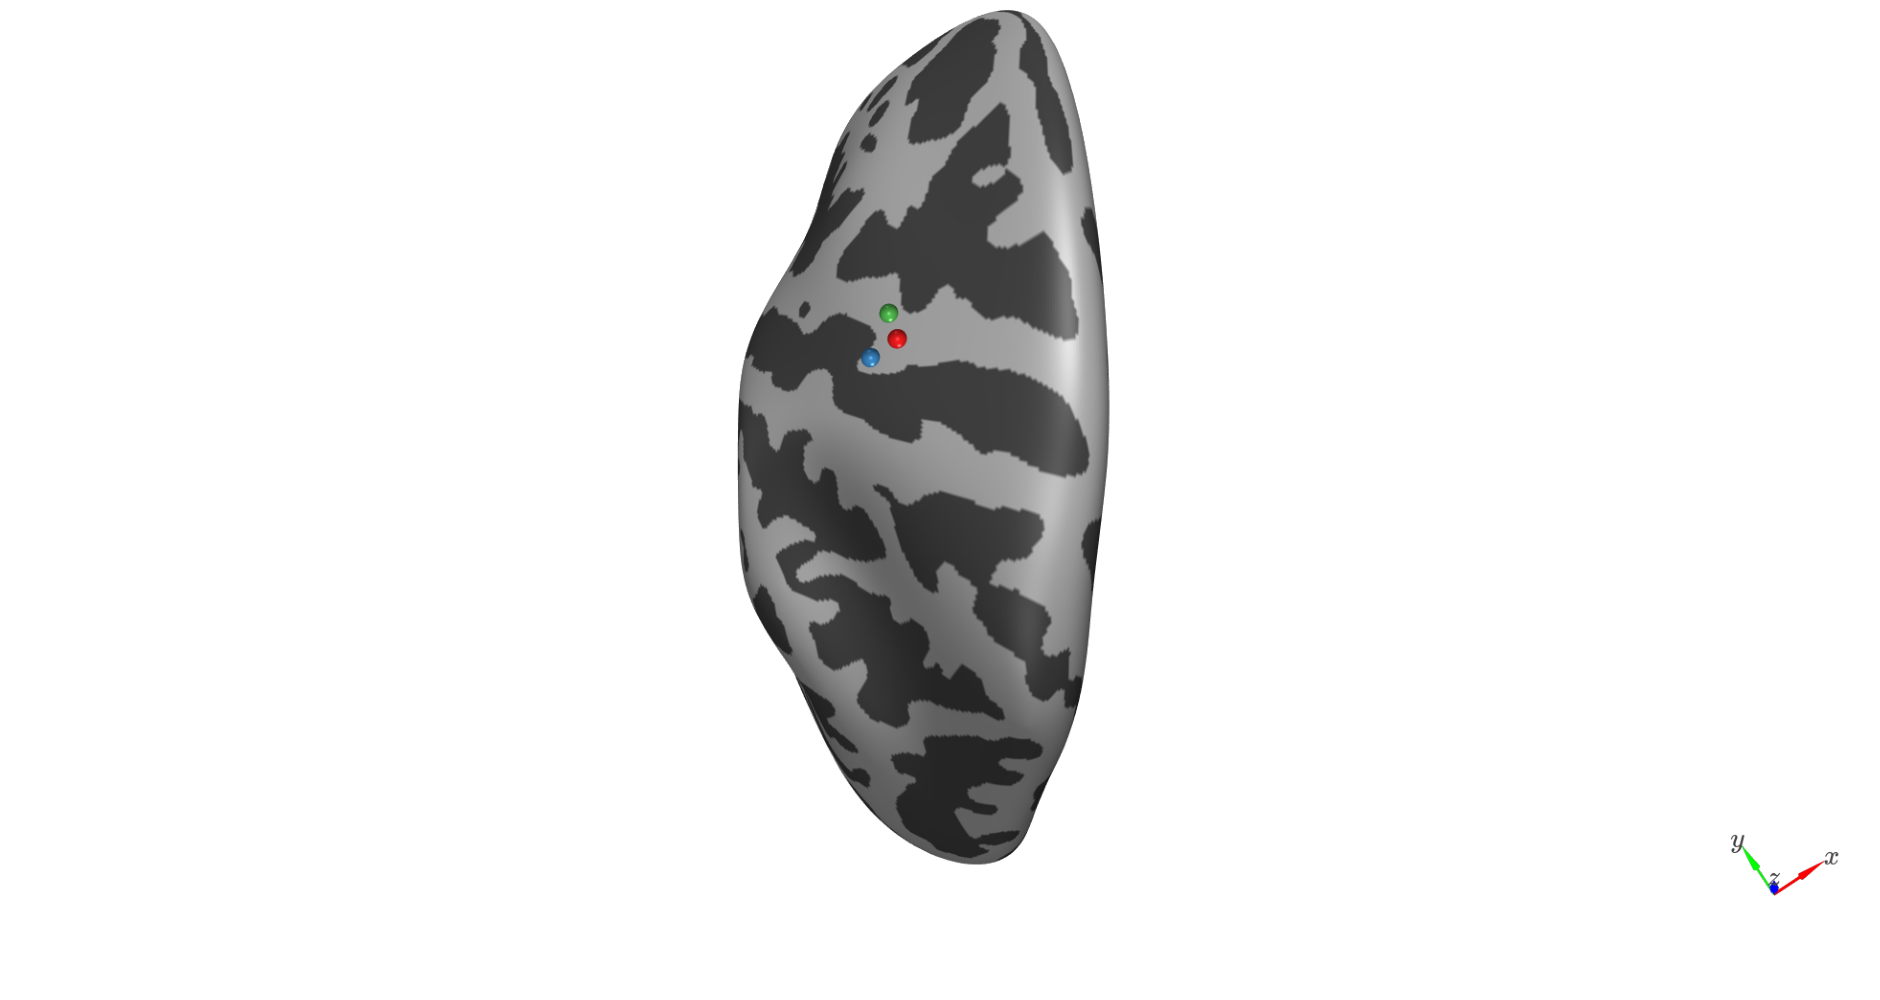

In [32]:
image_data = b64decode(plot.screenshot)

image = Image.open(io.BytesIO(image_data))

image_array = np.array(image)

plt.figure(figsize=(24,16))
plt.imshow(image_array)
plt.axis('off')  # To turn off the axis
plt.savefig('./figure_S7_btn_trial_mf_localization.pdf')

In [8]:
def align_to_peak(X, ref_idx=0):
    X = np.asarray(X)
    n_series, n_time = X.shape
    ref_peak = int(np.argmin(X[ref_idx]))
    peaks = np.argmin(X, axis=1).astype(int)
    lags = ref_peak - peaks                     # +lag -> shift right
    base = np.arange(n_time)
    align_idx = [np.clip(base - lag, 0, n_time - 1) for lag in lags]
    return lags, align_idx

lags, align_idx = align_to_peak(all_prior_ts)

aligned_snrs = []
aligned_prior_ts = []
aligned_layer_F = []
aligned_layer_F_diff = []

for ss_idx in range(all_prior_ts.shape[0]):
    aligned_idx = align_idx[ss_idx]

    aligned_snrs.append(all_snrs[ss_idx, aligned_idx])
    aligned_prior_ts.append(all_prior_ts[ss_idx, aligned_idx])
    aligned_layer_F.append(all_layer_F[ss_idx, :, aligned_idx])
    aligned_layer_F_diff.append(all_layer_F_diff[ss_idx, :, aligned_idx])

aligned_snrs = np.array(aligned_snrs)
aligned_prior_ts = np.array(aligned_prior_ts)
aligned_layer_F = np.transpose(np.array(aligned_layer_F), (0, 2, 1))
aligned_layer_F_diff = np.transpose(np.array(aligned_layer_F_diff), (0, 2, 1))


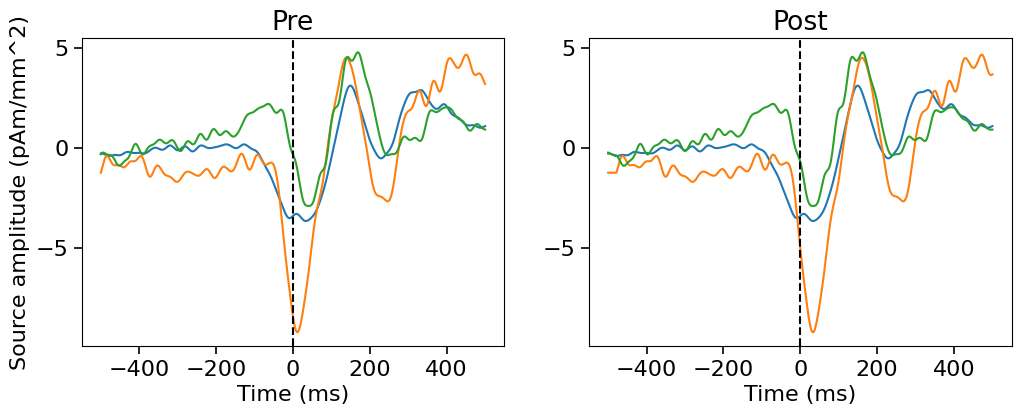

In [9]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ts_time, all_prior_ts.T)
plt.xlabel('Time (ms)')
plt.ylabel('Source amplitude (pAm/mm^2)')
plt.title('Pre')
plt.axvline(0, color='k', linestyle='--')

plt.subplot(1,2,2)
plt.plot(ts_time, aligned_prior_ts.T)
plt.xlabel('Time (ms)')
plt.title('Post')
plt.axvline(0, color='k', linestyle='--')

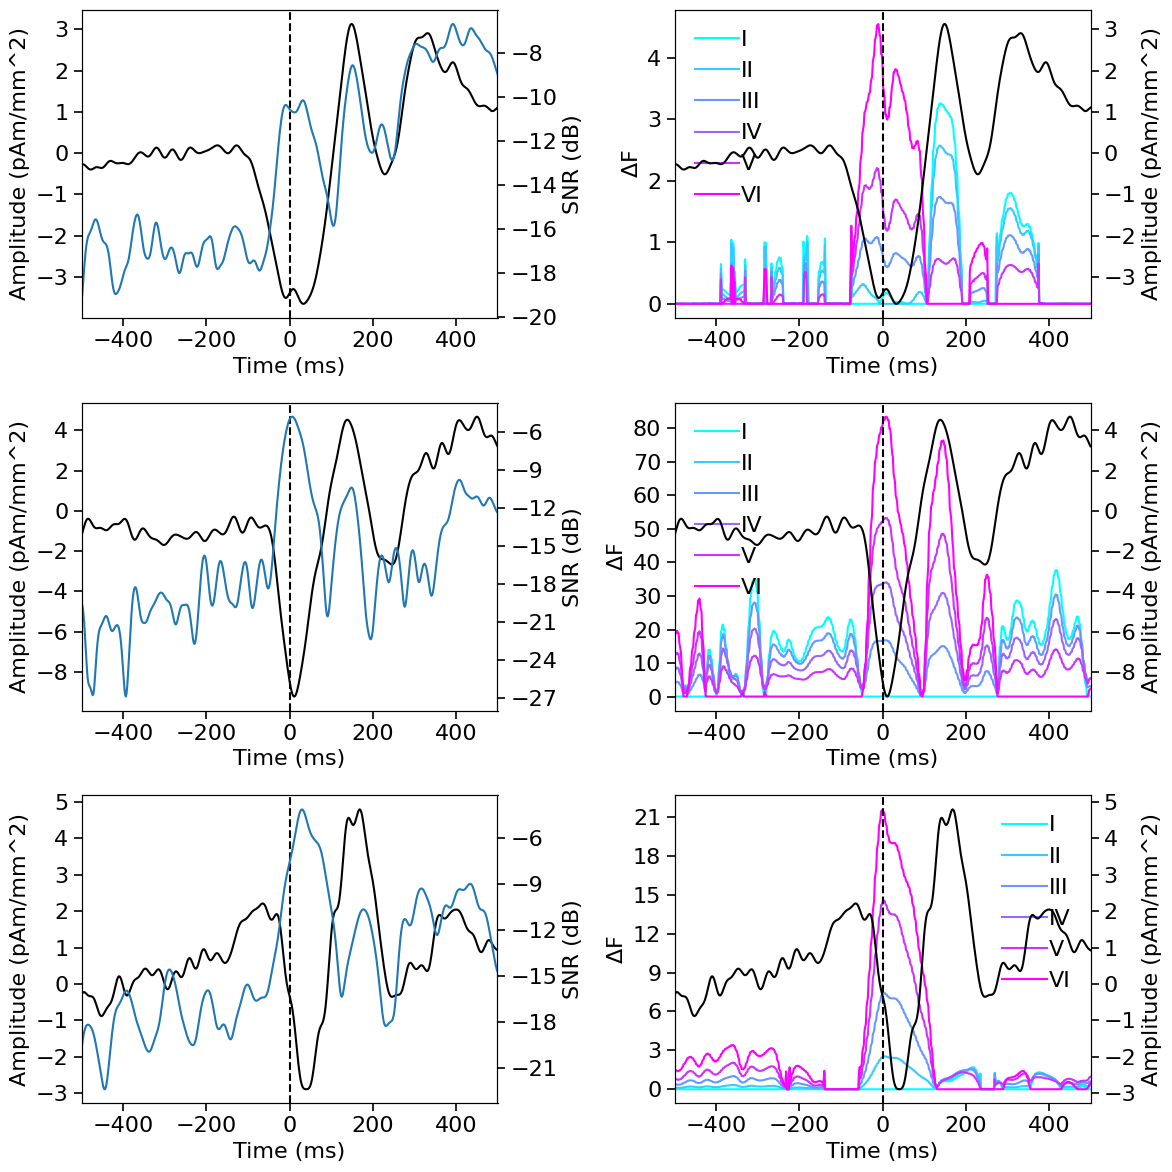

In [10]:
subjects_m_snrs = []
subjects_m_prior_ts = []
subjects_m_layer_F = []
subjects_m_layer_F_diff = []

fig=plt.figure(figsize=(12,4*len(subjects)))

for s_idx, subject in enumerate(subjects):
    subj_m_snrs = all_snrs[s_idx,:]
    subj_m_prior_ts = all_prior_ts[s_idx,:]
    subj_m_layer_F = all_layer_F[s_idx,:,:]
    subj_m_layer_F_diff = all_layer_F_diff[s_idx,:,:]

    subjects_m_snrs.append(subj_m_snrs)
    subjects_m_prior_ts.append(subj_m_prior_ts)
    subjects_m_layer_F.append(subj_m_layer_F)
    subjects_m_layer_F_diff.append(subj_m_layer_F_diff)

    ax=plt.subplot(len(subjects),2,s_idx*2+1)
    ax.plot(ts_time,subj_m_prior_ts,'k')
    ax.axvline(x=0, color='k', linestyle='--')
    ax.set_ylabel('Amplitude (pAm/mm^2)')
    ax.set_xlabel('Time (ms)')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2=ax.twinx()
    ax2.plot(sensor_time, subj_m_snrs)
    ax2.set_ylabel('SNR (dB)')
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(time_lims)

    ax=plt.subplot(len(subjects),2,s_idx*2+2)
    col_l = plt.cm.cool(np.linspace(0,1, num=6))
    l_labels=['I','II','III','IV','V','VI']
    for i in range(6):
        ax.plot(woi_win, subj_m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
    ax.axvline(x=0, color='k', linestyle='--')
    plt.legend()
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel(r'$\Delta$F')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2=ax.twinx()
    ax2.plot(ts_time,subj_m_prior_ts,'k')
    ax2.set_ylabel('Amplitude (pAm/mm^2)')
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(time_lims)

plt.tight_layout()
   
plt.savefig('./figure_SX_btn_trial_mf_subjects.pdf')

subjects_m_snrs = np.array(subjects_m_snrs)
subjects_m_prior_ts = np.array(subjects_m_prior_ts)
subjects_m_layer_F = np.array(subjects_m_layer_F)
subjects_m_layer_F_diff = np.array(subjects_m_layer_F_diff)

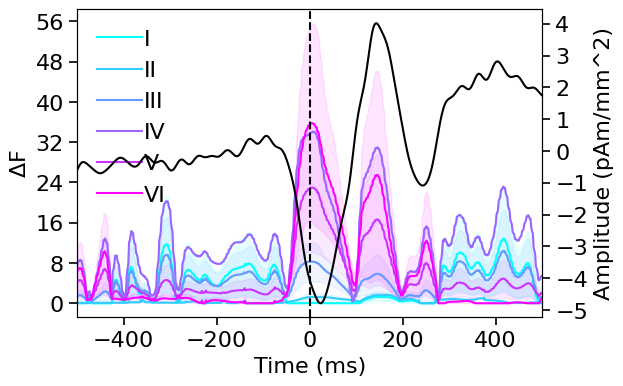

In [11]:
m_prior_ts=np.mean(subjects_m_prior_ts,axis=0)
m_layer_F_diff=np.nanmean(subjects_m_layer_F_diff,axis=0)
se_layer_F_diff=np.nanstd(subjects_m_layer_F_diff,axis=0)/np.sqrt(subjects_m_layer_F_diff.shape[0])

fig=plt.figure(figsize=(6,4))

ax=plt.subplot(1,1,1)
col_l = plt.cm.cool(np.linspace(0,1, num=6))
l_labels=['I','II','III','IV','V','VI']
for i in range(6):
    ax.plot(woi_win, m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
    ax.fill_between(woi_win, m_layer_F_diff[i,:]-se_layer_F_diff[i,:], m_layer_F_diff[i,:]+se_layer_F_diff[i,:], color=col_l[i], alpha=0.1)
ax.axvline(x=0, color='k', linestyle='--')
plt.legend()
ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'$\Delta$F')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax2=ax.twinx()
ax2.plot(ts_time,m_prior_ts,'k')
ax2.set_ylabel('Amplitude (pAm/mm^2)')
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlim(time_lims)

plt.savefig('./figure_SX_btn_trial_mf.pdf')

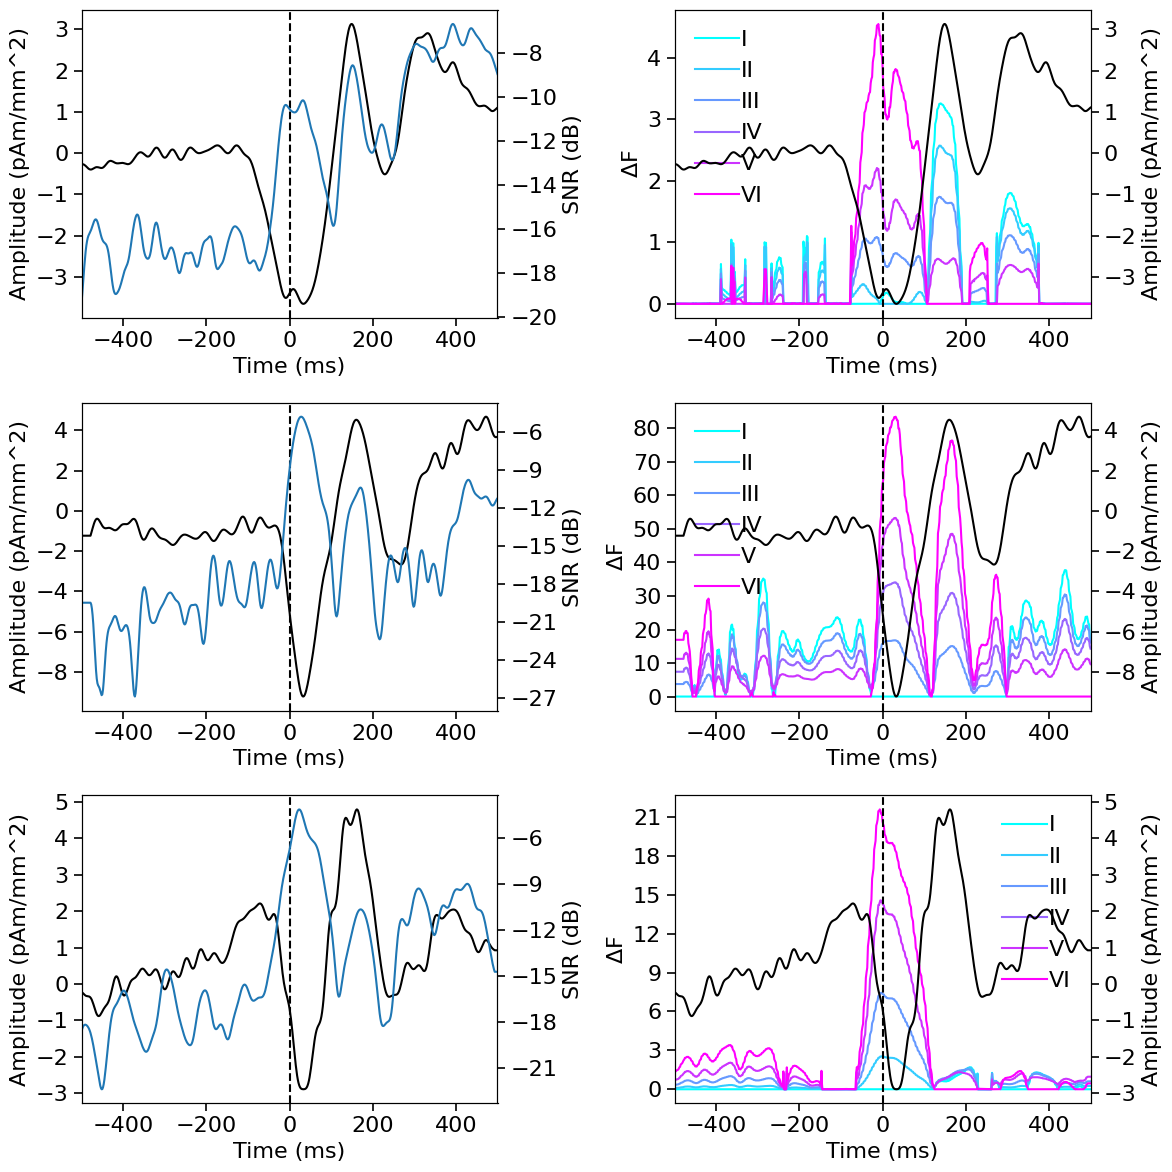

In [12]:
aligned_subjects_m_snrs = []
aligned_subjects_m_prior_ts = []
aligned_subjects_m_layer_F = []
aligned_subjects_m_layer_F_diff = []

fig=plt.figure(figsize=(12,4*len(subjects)))

for s_idx, subject in enumerate(subjects):
    subj_m_snrs = aligned_snrs[s_idx,:]
    subj_m_prior_ts = aligned_prior_ts[s_idx,:]
    subj_m_layer_F = aligned_layer_F[s_idx,:,:]
    subj_m_layer_F_diff = aligned_layer_F_diff[s_idx,:,:]

    aligned_subjects_m_snrs.append(subj_m_snrs)
    aligned_subjects_m_prior_ts.append(subj_m_prior_ts)
    aligned_subjects_m_layer_F.append(subj_m_layer_F)
    aligned_subjects_m_layer_F_diff.append(subj_m_layer_F_diff)

    ax=plt.subplot(len(subjects),2,s_idx*2+1)
    ax.plot(ts_time,subj_m_prior_ts,'k')
    ax.axvline(x=0, color='k', linestyle='--')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (pAm/mm^2)')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2=ax.twinx()
    ax2.plot(sensor_time, subj_m_snrs)
    ax2.set_ylabel('SNR (dB)')
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(time_lims)

    ax=plt.subplot(len(subjects),2,s_idx*2+2)
    col_l = plt.cm.cool(np.linspace(0,1, num=6))
    l_labels=['I','II','III','IV','V','VI']
    for i in range(6):
        ax.plot(woi_win, subj_m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
    ax.axvline(x=0, color='k', linestyle='--')
    plt.legend()
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel(r'$\Delta$F')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2=ax.twinx()
    ax2.plot(ts_time,subj_m_prior_ts,'k')
    ax2.set_ylabel('Amplitude (pAm/mm^2)')
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlim(time_lims)

plt.tight_layout()

plt.savefig('./figure_SX_btn_trial_mf_subjects_aligned.pdf')

aligned_subjects_m_snrs = np.array(aligned_subjects_m_snrs)
aligned_subjects_m_prior_ts = np.array(aligned_subjects_m_prior_ts)
aligned_subjects_m_layer_F = np.array(aligned_subjects_m_layer_F)
aligned_subjects_m_layer_F_diff = np.array(aligned_subjects_m_layer_F_diff)


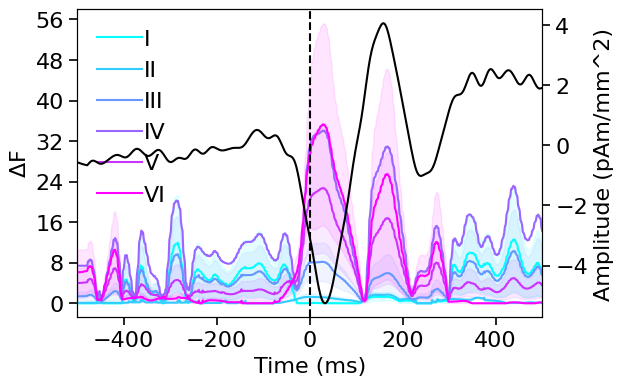

In [13]:
m_prior_ts=np.mean(aligned_subjects_m_prior_ts,axis=0)
m_layer_F_diff=np.nanmean(aligned_subjects_m_layer_F_diff,axis=0)
se_layer_F_diff=np.nanstd(aligned_subjects_m_layer_F_diff,axis=0)/np.sqrt(aligned_subjects_m_layer_F_diff.shape[0])

fig=plt.figure(figsize=(6,4))

ax=plt.subplot(1,1,1)
col_l = plt.cm.cool(np.linspace(0,1, num=6))

l_labels=['I','II','III','IV','V','VI']
for i in range(6):
    ax.plot(woi_win, m_layer_F_diff[i,:],label=l_labels[i],color=col_l[i])
    ax.fill_between(woi_win, m_layer_F_diff[i,:]-se_layer_F_diff[i,:], m_layer_F_diff[i,:]+se_layer_F_diff[i,:],color=col_l[i], alpha=0.1)
ax.axvline(x=0, color='k', linestyle='--')
plt.legend()


ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'$\Delta$F')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax2=ax.twinx()
ax2.plot(ts_time,m_prior_ts,'k')
ax2.set_ylabel('Amplitude (pAm/mm^2)')
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlim(time_lims)


plt.savefig('./figure_S7_btn_trial_mf_aligned.pdf')